# Triton vecadd
The code is adapted from [triton-lang.org](https://triton-lang.org/main/getting-started/tutorials/01-vector-add.html).

In [1]:
import triton
import triton.language as tl

DEVICE = triton.runtime.driver.active.get_active_torch_device()

@triton.jit
def add_kernel(x_ptr, y_ptr, output_ptr, n_elements, BLOCK_SIZE: tl.constexpr):
    pid = tl.program_id(axis=0)
    block_start = pid * BLOCK_SIZE
    offsets = block_start + tl.arange(0, BLOCK_SIZE)
    mask = offsets < n_elements
    x = tl.load(x_ptr + offsets, mask=mask)
    y = tl.load(y_ptr + offsets, mask=mask)
    output = x + y
    tl.store(output_ptr + offsets, output, mask=mask)

In [2]:
import torch


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["size"],
        x_vals=[2**i for i in range(12, 28, 1)],
        x_log=True,
        line_arg="provider",
        line_vals=["triton", "torch"],
        line_names=["Triton", "Torch"],
        styles=[("blue", "-"), ("green", "-")],
        ylabel="GB/s",
        plot_name="vector-add-performance",
        args={},
    )
)
def benchmark(size, provider):
    x = torch.rand(size, device=DEVICE, dtype=torch.float32)
    y = torch.rand(size, device=DEVICE, dtype=torch.float32)
    output = torch.empty_like(x)
    grid = lambda meta: (triton.cdiv(size, meta["BLOCK_SIZE"]),)
    quantiles = [0.5, 0.2, 0.8]
    if provider == "torch":
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: x + y, quantiles=quantiles)
    if provider == "triton":
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: add_kernel[grid](x, y, output, size, BLOCK_SIZE=512),
            quantiles=quantiles,
        )
    gbps = lambda ms: 3 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms), gbps(max_ms), gbps(min_ms)

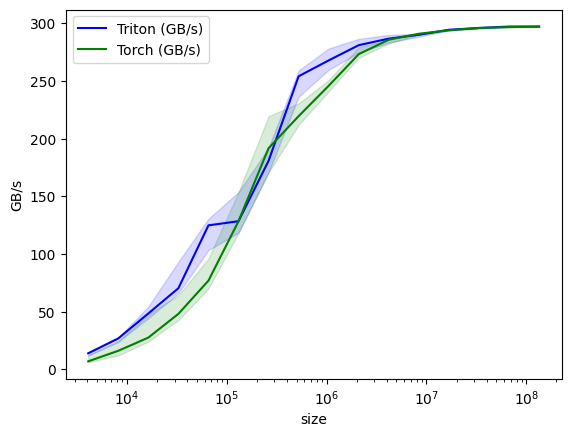

vector-add-performance:
           size  Triton (GB/s)  Torch (GB/s)
0        4096.0      13.837838      6.857143
1        8192.0      26.713043     15.999999
2       16384.0      48.377950     27.428571
3       32768.0      70.217145     48.000000
4       65536.0     124.751268     76.800002
5      131072.0     128.334202    128.334202
6      262144.0     180.705879    191.625729
7      524288.0     254.015499    219.428568
8     1048576.0     267.767108    245.760006
9     2097152.0     280.968928    273.161511
10    4194304.0     286.652810    285.715543
11    8388608.0     289.982309    290.840226
12   16777216.0     294.323343    293.883420
13   33554432.0     295.873591    295.873591
14   67108864.0     297.103147    296.651338
15  134217728.0     297.145227    296.990947


In [3]:
benchmark.run(print_data=True, show_plots=True)